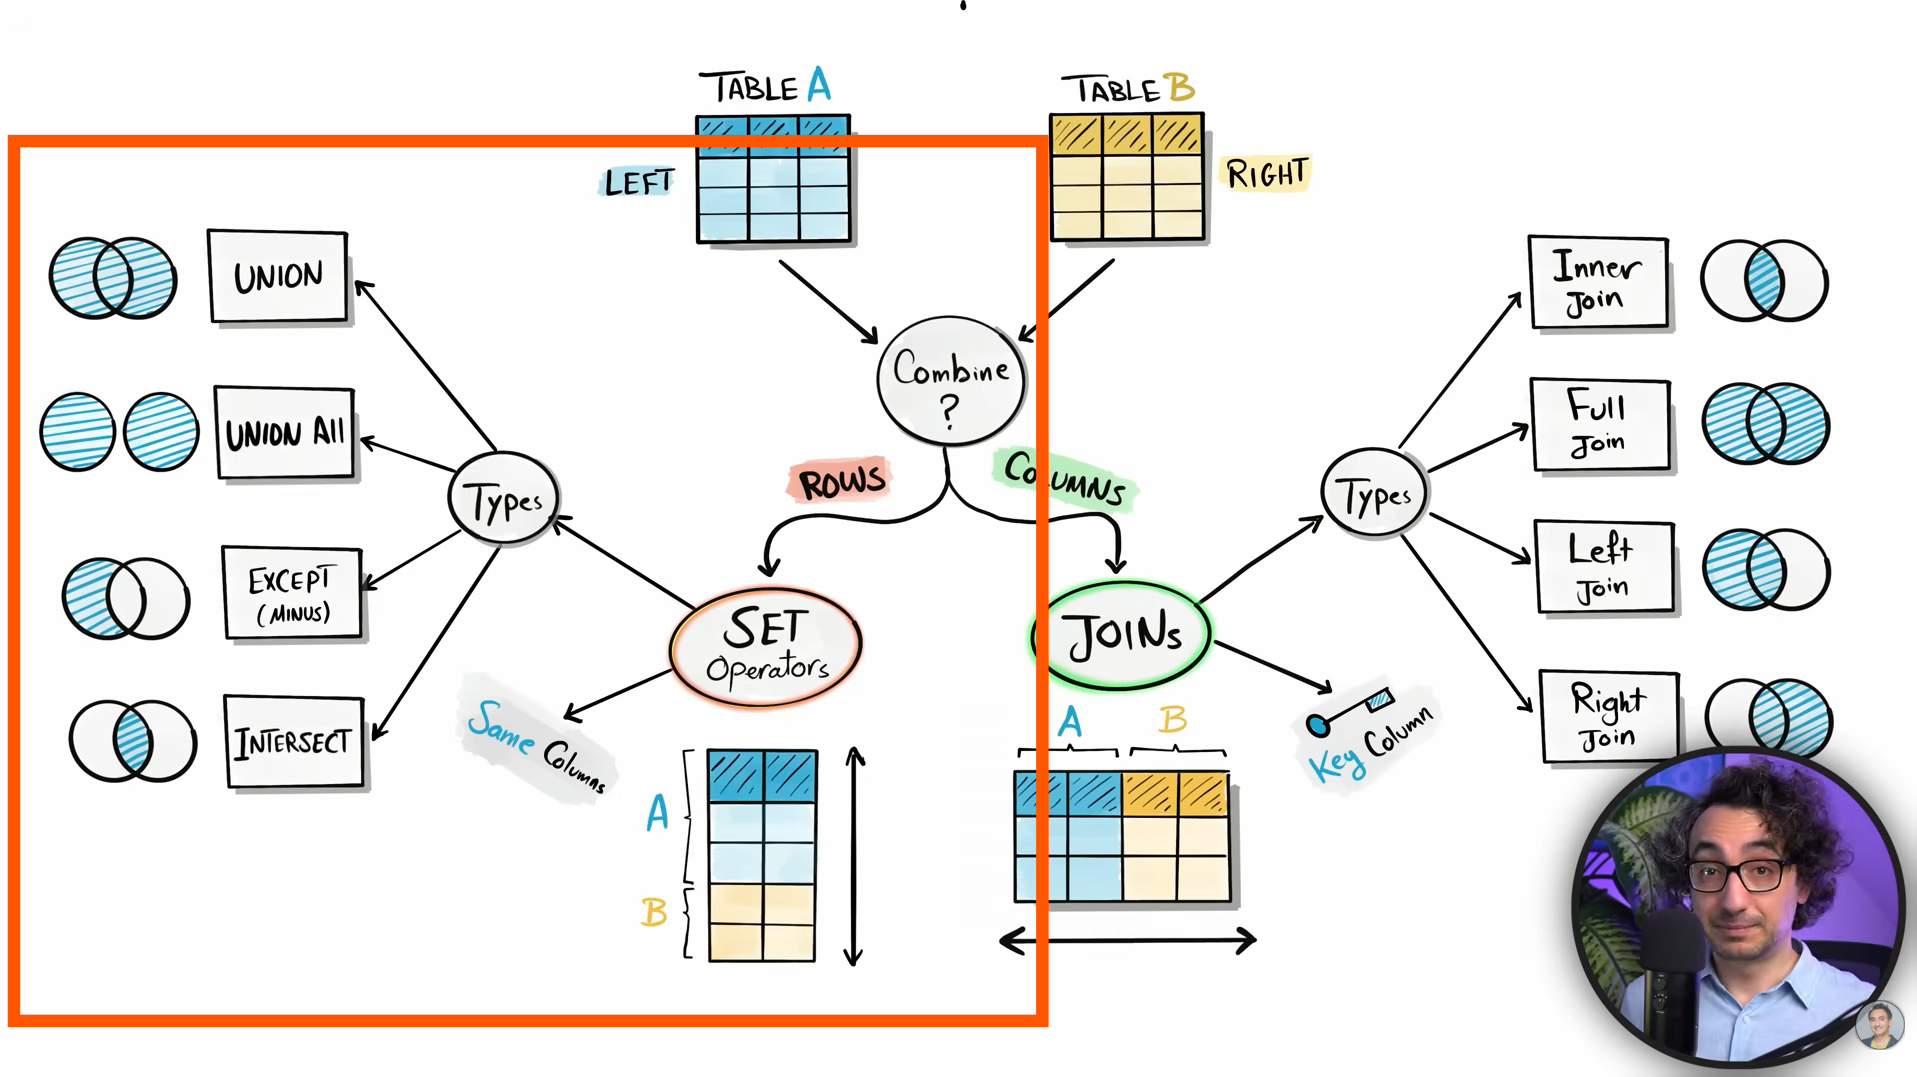

## Rules of the SET operator

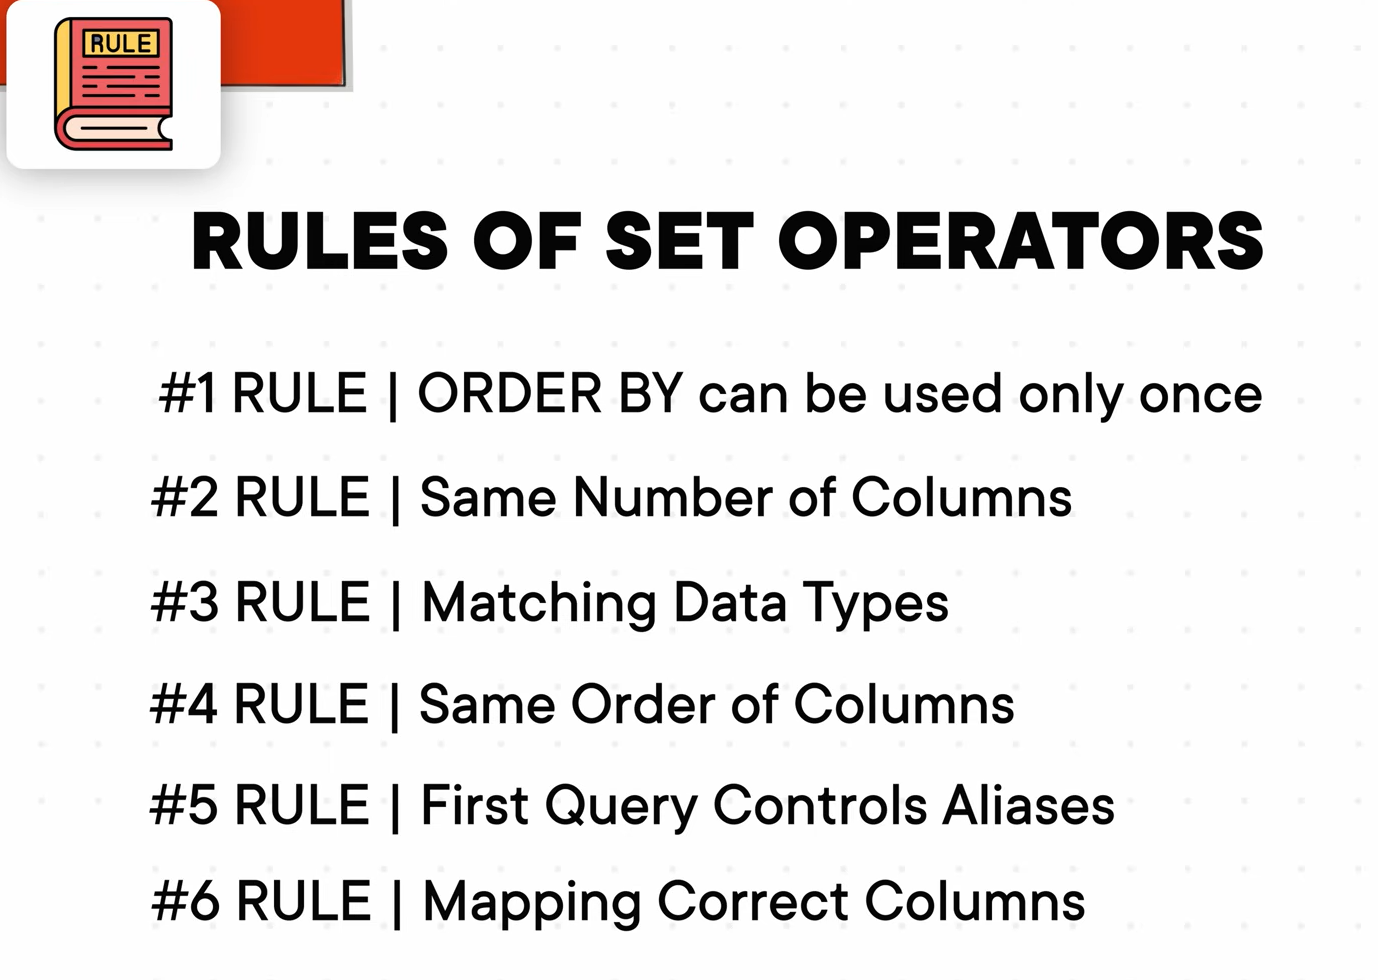

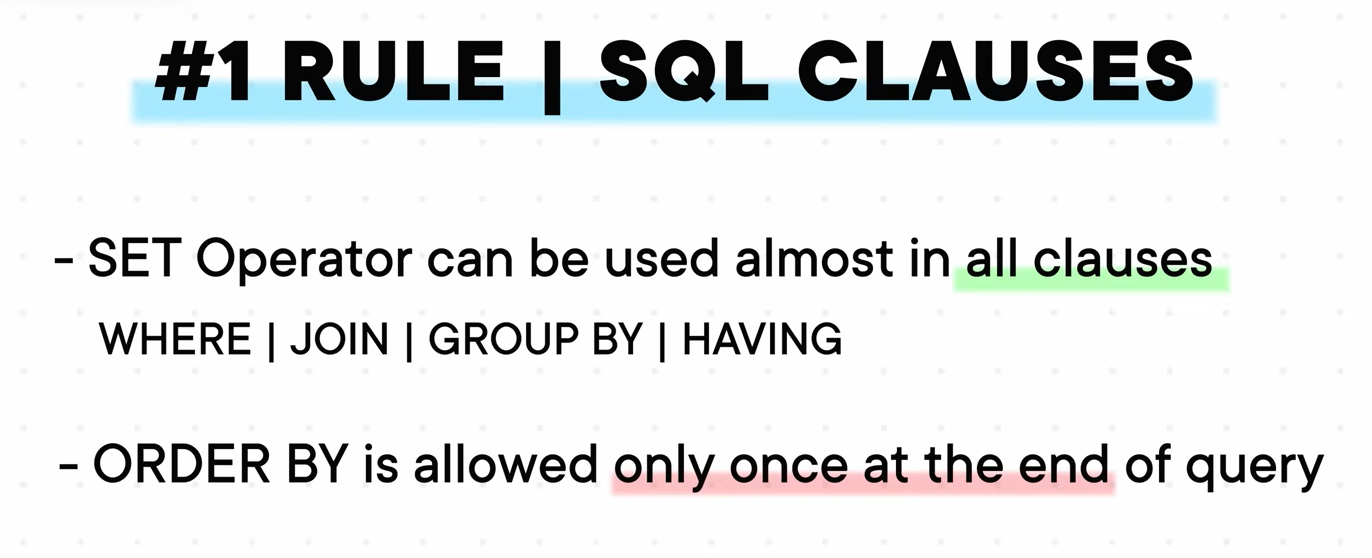

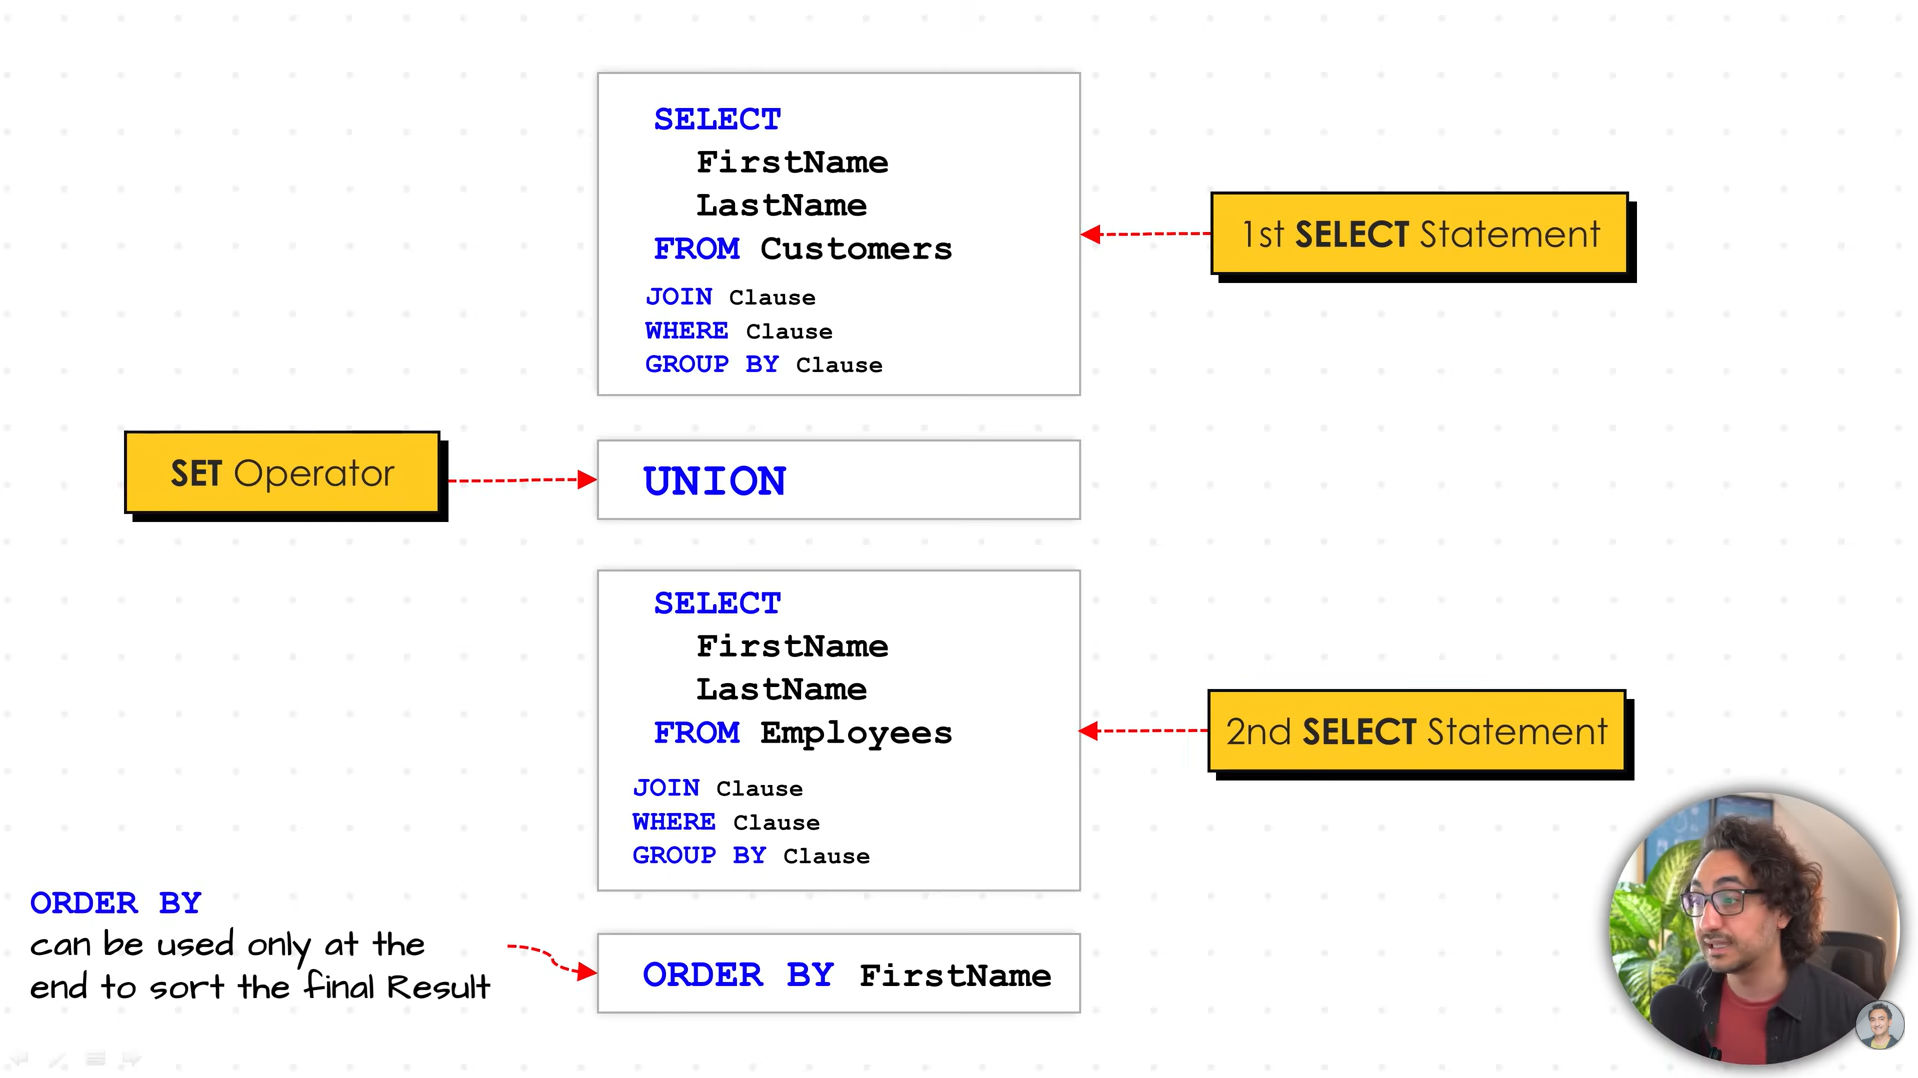

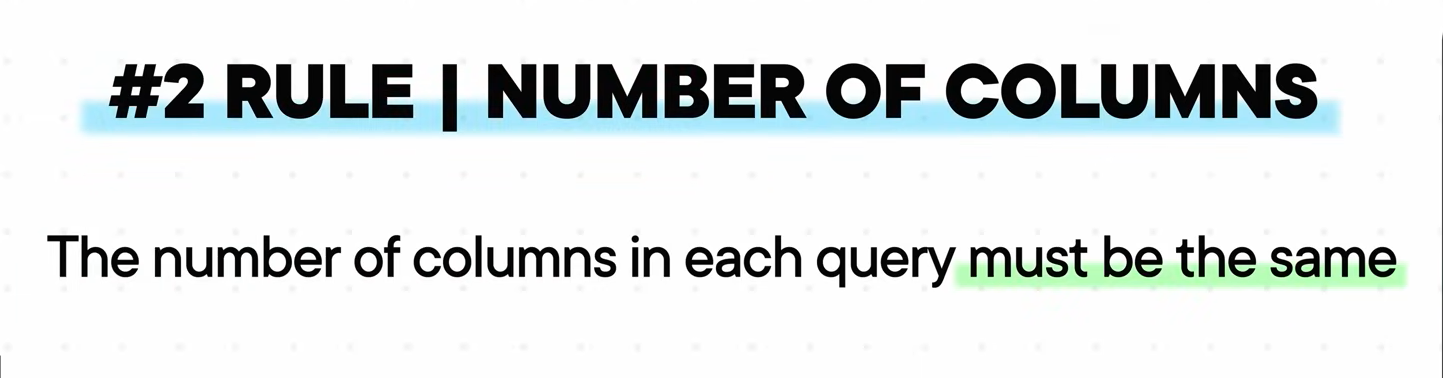

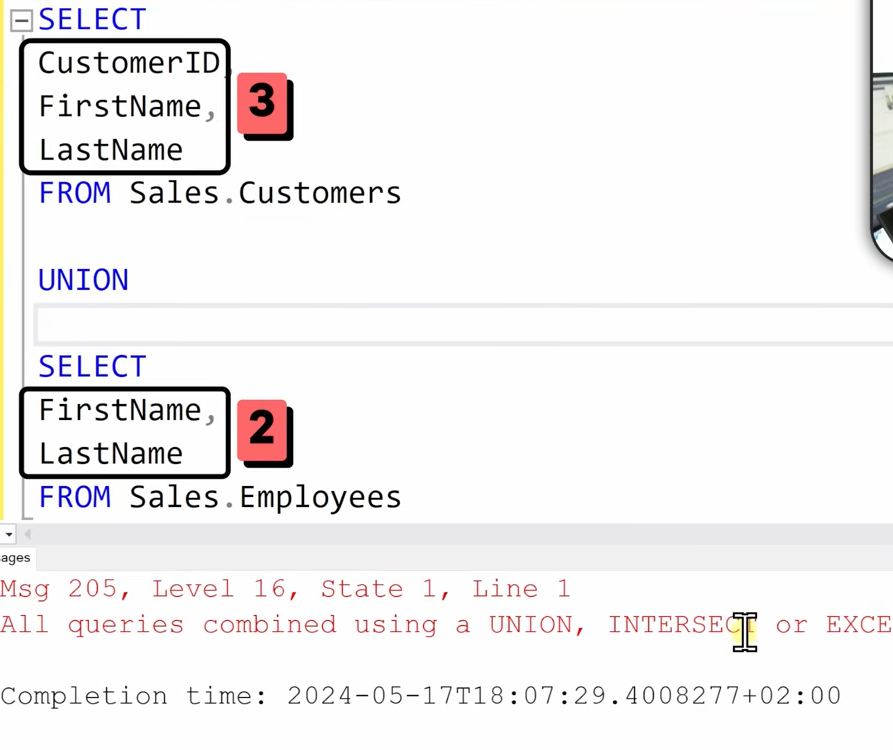

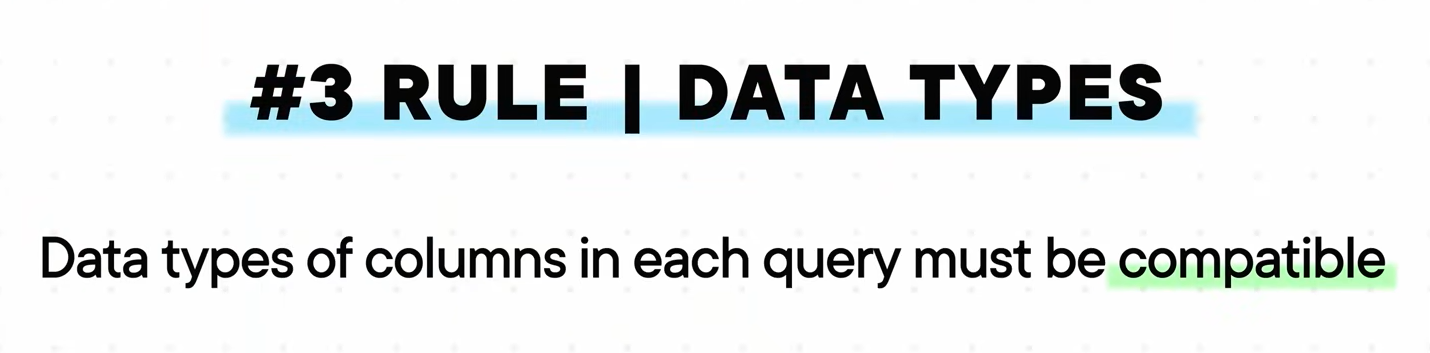

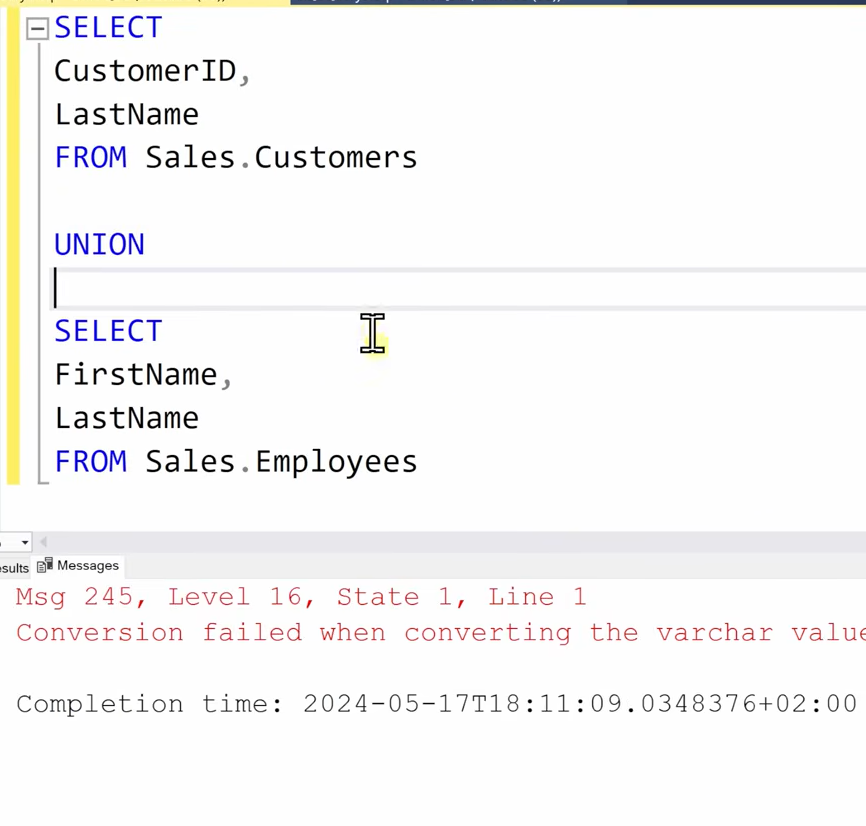

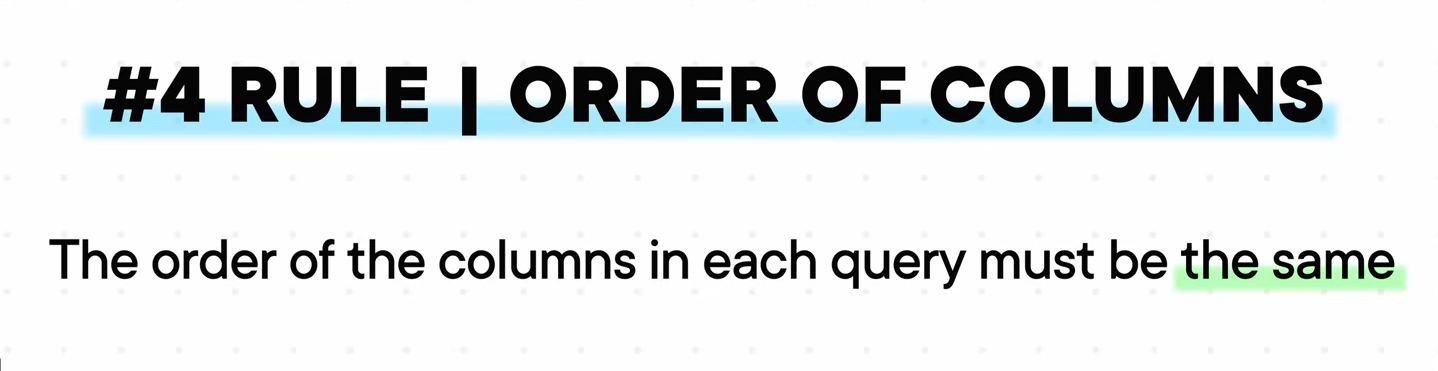

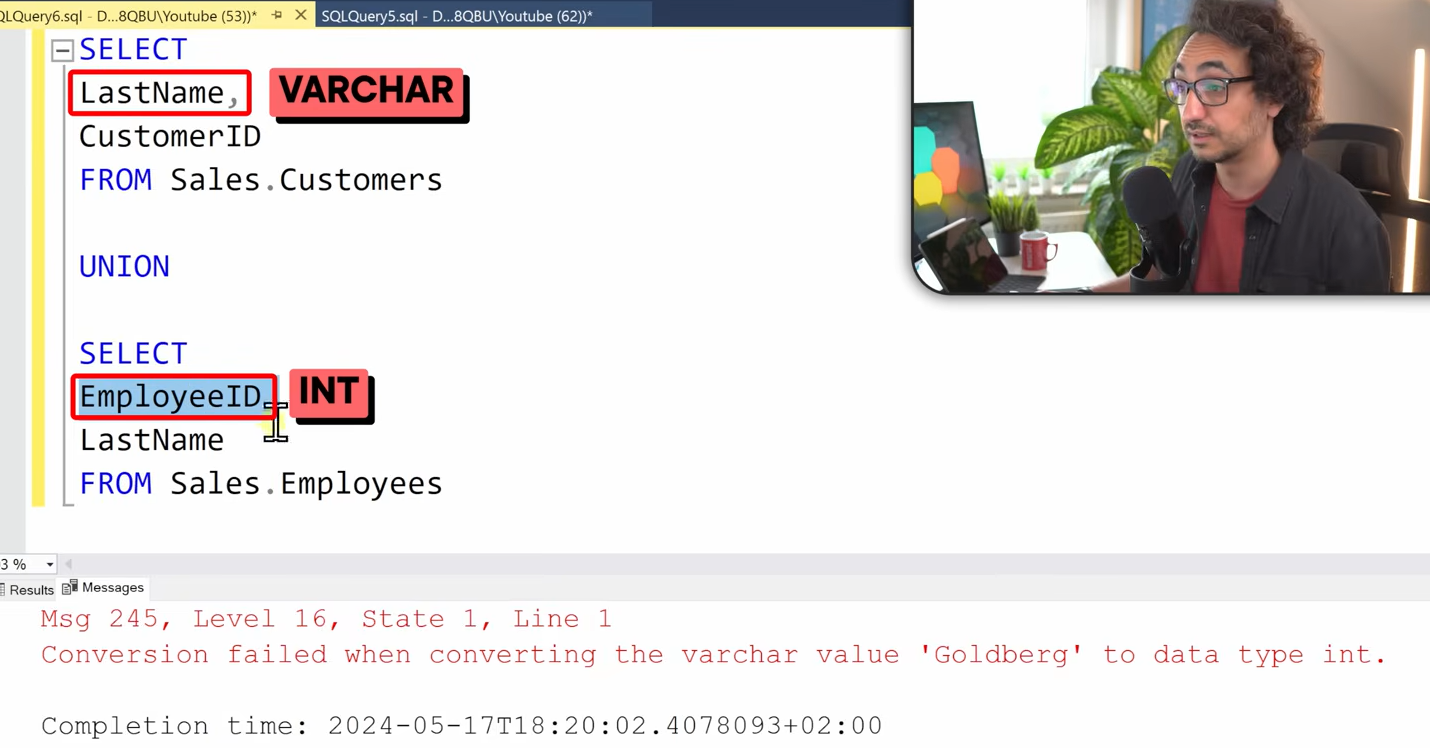

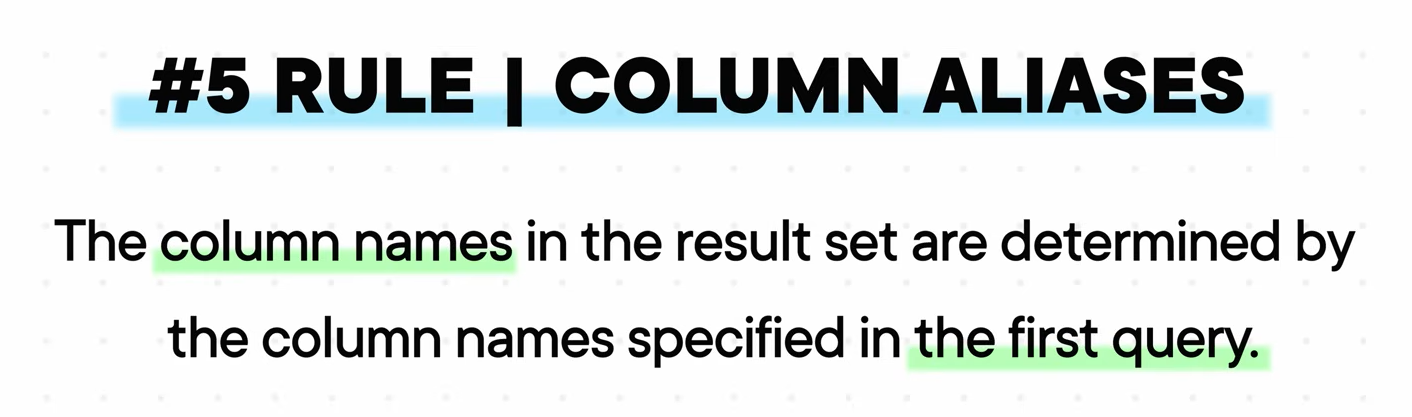

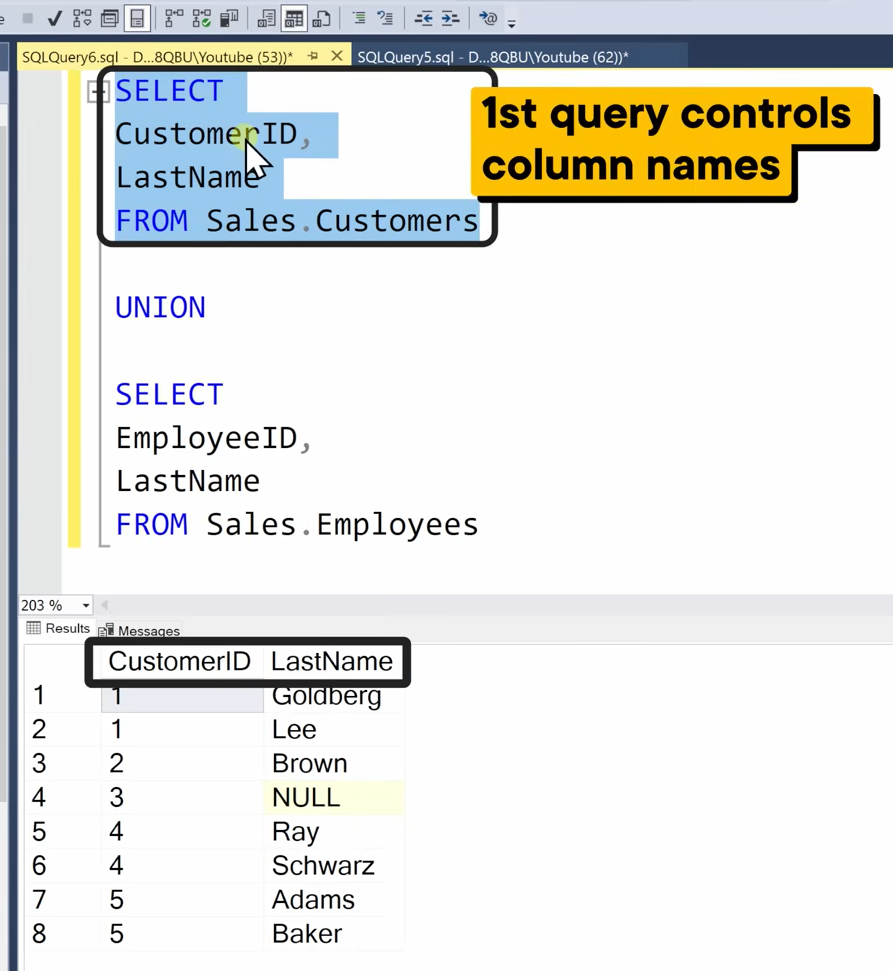

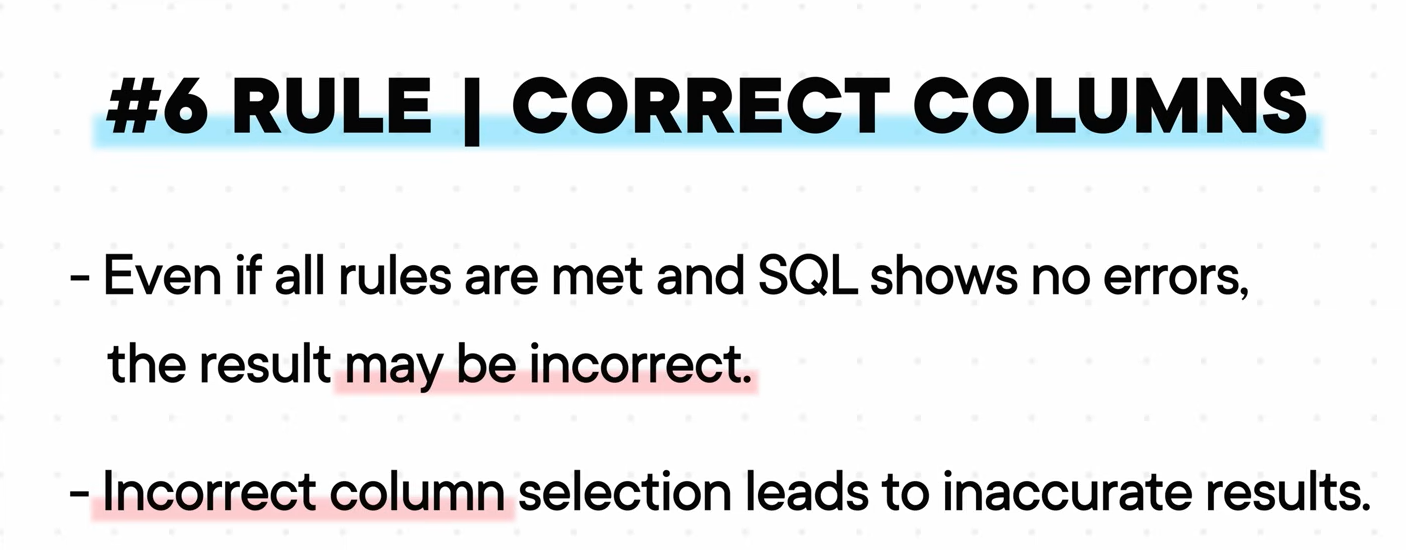

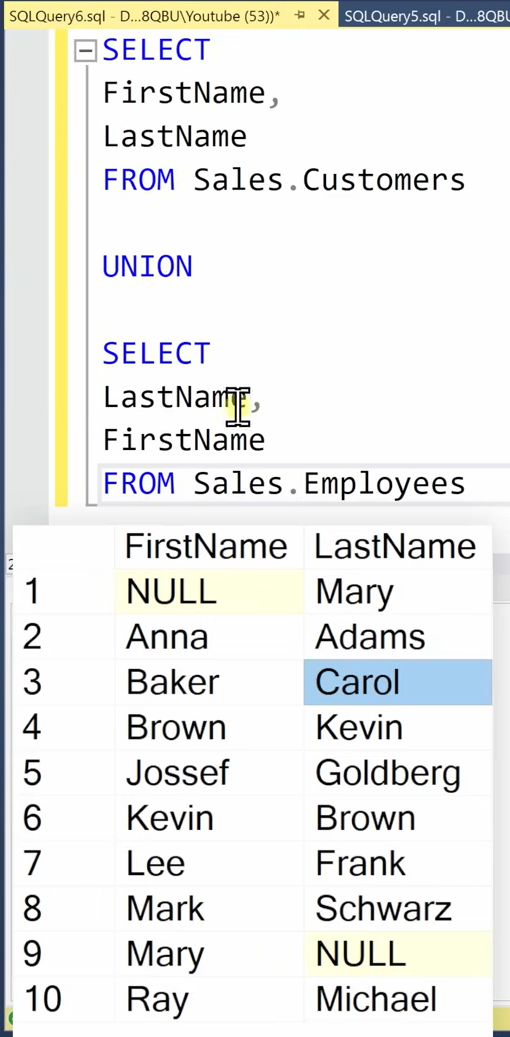

## SET Operators : 

### UNION : Returns all distinct rows from both queries (No Duplicate)

#### Combine the data from employees and customers into one table

In [7]:
%%sql
select employeeid, firstname, lastname from  employees
union 
select customerid, firstname, lastname from customers;

Running query in 'mysql+pymysql://'

8 rows affected.

employeeid,firstname,lastname
1,Frank,Lee
2,Kevin,Brown
3,Mary,None
4,Michael,Ray
5,Carol,Baker
1,Jossef,Goldberg
4,Mark,Schwarz
5,Anna,Adams


In [ ]:
%%sql
select * from customers;

Running query in 'mysql+pymysql://'

5 rows affected.

customerid,firstname,lastname,country,score
1,Jossef,Goldberg,Germany,350
2,Kevin,Brown,USA,900
3,Mary,None,USA,750
4,Mark,Schwarz,Germany,500
5,Anna,Adams,USA,None


In [5]:
%%sql
select * from employees;

Running query in 'mysql+pymysql://'

5 rows affected.

employeeid,firstname,lastname,department,birthdate,gender,salary,managerid
1,Frank,Lee,Marketing,1988-12-05,M,55000,None
2,Kevin,Brown,Marketing,1972-11-25,M,65000,1
3,Mary,None,Sales,1986-01-05,F,75000,1
4,Michael,Ray,Sales,1977-02-10,M,90000,2
5,Carol,Baker,Sales,1982-02-11,F,55000,3


### UNION ALL : Returns ALL ROWS from both queries (INCLUDE DUPLICATES)
```
1. UNION ALL is faster than UNION
2. Use UNION ALL when you want to find DUPLICATES and Data Quality Issues
```

#### Combines the data from employees and customers into one table including duplicates.

In [10]:
%%sql
select employeeid,
    firstname,
    lastname
from employees

union all

select customerid,
    firstname,
    lastname
from customers;

Running query in 'mysql+pymysql://'

10 rows affected.

employeeid,firstname,lastname
1,Frank,Lee
2,Kevin,Brown
3,Mary,None
4,Michael,Ray
5,Carol,Baker
1,Jossef,Goldberg
2,Kevin,Brown
3,Mary,None
4,Mark,Schwarz
5,Anna,Adams


### EXCEPT : 
```
- Returns all Distinct rows from the foirst query that are not found in the second query.
- It is the only one operator where the order of queries affects the final result.
- Also have same function like MINUS
```

#### Syntax :
```
SELECT * FROM tableOne
EXCEPT
SELECT * FROM tableTwo;
```

#### Find the Employees who are not customers at the same time.

In [5]:
%%sql
select firstname,
    lastname
from employees
EXCEPT
select firstname,
    lastname
from customers;

Running query in 'mysql+pymysql://'

3 rows affected.

firstname,lastname
Frank,Lee
Michael,Ray
Carol,Baker


### INTERSECT : Returns common rows between two tables

#### Syntax :
```
SELECT * FROM tableOne
INTERSECT 
SELECT * FROM tableTwo;
```

#### Find the Employees who are also Customers.

In [8]:
%%sql
select firstname,
    lastname
from employees
INTERSECT
select firstname,
    lastname
from customers;

Running query in 'mysql+pymysql://'

2 rows affected.

firstname,lastname
Kevin,Brown
Mary,None


### UNION USE CASES

#### Orders data are stored in separate tables (Orders and OrdersArchive), combine all orders data into one report without duplicates.

In [9]:
%%sql
select * from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,productid,customerid,salespersonid,orderdate,shipdate,orderstatus,shipaddress,billaddress,quantity,sales,creationtime
1,101,2,3,2025-01-01,2025-01-05,Delivered,9833 Mt. Dias Blv.,1226 Shoe St.,1,10,2025-01-01 12:34:56
2,102,3,3,2025-01-05,2025-01-10,Shipped,250 Race Court,None,1,15,2025-01-05 23:22:04
3,101,1,5,2025-01-10,2025-01-25,Delivered,8157 W. Book,8157 W. Book,2,20,2025-01-10 18:24:08
4,105,1,3,2025-01-20,2025-01-25,Shipped,5724 Victory Lane,,2,60,2025-01-20 05:50:33
5,104,2,5,2025-02-01,2025-02-05,Delivered,None,None,1,25,2025-02-01 14:02:41
6,104,3,5,2025-02-05,2025-02-10,Delivered,1792 Belmont Rd.,None,2,50,2025-02-06 15:34:57
7,102,1,1,2025-02-15,2025-02-27,Delivered,136 Balboa Court,,2,30,2025-02-16 06:22:01
8,101,4,3,2025-02-18,2025-02-27,Shipped,2947 Vine Lane,4311 Clay Rd,3,90,2025-02-18 10:45:22
9,101,2,3,2025-03-10,2025-03-15,Shipped,3768 Door Way,,2,20,2025-03-10 12:59:04
10,102,3,5,2025-03-15,2025-03-20,Shipped,None,None,0,60,2025-03-16 23:25:15


In [2]:
%%sql
select * from orders_archive;

Running query in 'mysql+pymysql://'

archive_id,orderid,productid,customerid,salespersonid,orderdate,shipdate,orderstatus,shipaddress,billaddress,quantity,sales,creationtime


In [11]:
%%sql
select o.orderid,
    o.productid,
    o.customerid,
    o.salespersonid,
    o.orderdate,
    o.shipdate,
    o.orderstatus,
    o.shipaddress,
    o.billaddress,
    o.quantity,
    o.sales,
    o.creationtime
from orders as o
UNION
select oa.orderid,
    oa.productid,
    oa.customerid,
    oa.salespersonid,
    oa.orderdate,
    oa.shipdate,
    oa.orderstatus,
    oa.shipaddress,
    oa.billaddress,
    oa.quantity,
    oa.sales,
    oa.creationtime
from orders_archive as oa;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,productid,customerid,salespersonid,orderdate,shipdate,orderstatus,shipaddress,billaddress,quantity,sales,creationtime
1,101,2,3,2025-01-01,2025-01-05,Delivered,9833 Mt. Dias Blv.,1226 Shoe St.,1,10,2025-01-01 12:34:56
2,102,3,3,2025-01-05,2025-01-10,Shipped,250 Race Court,None,1,15,2025-01-05 23:22:04
3,101,1,5,2025-01-10,2025-01-25,Delivered,8157 W. Book,8157 W. Book,2,20,2025-01-10 18:24:08
4,105,1,3,2025-01-20,2025-01-25,Shipped,5724 Victory Lane,,2,60,2025-01-20 05:50:33
5,104,2,5,2025-02-01,2025-02-05,Delivered,None,None,1,25,2025-02-01 14:02:41
6,104,3,5,2025-02-05,2025-02-10,Delivered,1792 Belmont Rd.,None,2,50,2025-02-06 15:34:57
7,102,1,1,2025-02-15,2025-02-27,Delivered,136 Balboa Court,,2,30,2025-02-16 06:22:01
8,101,4,3,2025-02-18,2025-02-27,Shipped,2947 Vine Lane,4311 Clay Rd,3,90,2025-02-18 10:45:22
9,101,2,3,2025-03-10,2025-03-15,Shipped,3768 Door Way,,2,20,2025-03-10 12:59:04
10,102,3,5,2025-03-15,2025-03-20,Shipped,None,None,0,60,2025-03-16 23:25:15
